In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel(
    "/content/drive/MyDrive/Data Analytics/Nigeria's Youth Unemployment Dataset Cleaned Sourced From ILOSTAT.xlsx"
)

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

Shape: (216, 7)

Columns: ['Sex Label', 'Age Group', 'Education Level', 'Time Period', 'Observed_Values', 'obs_status.label', 'note_indicator.label']

First 5 rows:
   Sex Label                 Age Group  \
0     Total  Age (Youth bands): 15-29   
1     Total  Age (Youth bands): 15-29   
2     Total  Age (Youth bands): 15-29   
3     Total  Age (Youth bands): 15-29   
4     Total  Age (Youth bands): 15-29   

                                 Education Level  Time Period  \
0            Education (Aggregate levels): Total         2024   
1  Education (Aggregate levels): Less than basic         2024   
2            Education (Aggregate levels): Basic         2024   
3     Education (Aggregate levels): Intermediate         2024   
4         Education (Aggregate levels): Advanced         2024   

   Observed_Values obs_status.label note_indicator.label  
0         2187.612              NaN                  NaN  
1           31.878              NaN                  NaN  
2          254.842 

In [ ]:
YEARS     = [2016, 2019, 2022, 2023, 2024]
YEAR_LBLS = [str(y) for y in YEARS]

In [ ]:
WHITE    = '#FFFFFF'
PANEL    = '#262626'
BG       = '#1A1A1A'
GRIDLINE = '#404040'
GREY     = '#808080'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'text.color':        WHITE,
    'axes.facecolor':    PANEL,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRIDLINE,
    'axes.labelcolor':   WHITE,
    'xtick.color':       GREY,
    'ytick.color':       GREY,
    'grid.color':        GRIDLINE,
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
})

In [ ]:
def save(fig, name):
    fig.savefig(name, dpi=180, bbox_inches='tight', facecolor=BG)
    print(f"Saved: {name}")

In [ ]:
MUTED = '#969696' # Defining MUTED color
def add_source(fig):
    fig.text(
        0.99, 0.012,
        "Source: ILOSTAT — International Labour Organization  |  Author: Onyiobazi Aquah",
        ha='right', va='bottom', fontsize=7.5, color=MUTED, style='italic'
    )

In [ ]:
trend = df[
    (df['Sex Label']       == 'Total') &
    (df['Age Group']       == 'Age (Youth bands): 15-29') &
    (df['Education Level'] == 'Education (Aggregate levels): Total')
].sort_values('Time Period')

trend_vals = trend['Observed_Values'].values / 1000

In [ ]:
edu_labels = {
    'Education (Aggregate levels): Less than basic': 'Less than Basic',
    'Education (Aggregate levels): Basic':           'Basic',
    'Education (Aggregate levels): Intermediate':    'Intermediate',
    'Education (Aggregate levels): Advanced':        'Advanced',
}

In [ ]:
edu_df = df[
    (df['Sex Label'] == 'Total') &
    (df['Age Group'] == 'Age (Youth bands): 15-29') &
    (df['Education Level'].isin(edu_labels.keys()))
].copy()

edu_df['Edu'] = edu_df['Education Level'].map(edu_labels)

In [ ]:
totals_by_year = df[
    (df['Sex Label'] == 'Total') &
    (df['Age Group'] == 'Age (Youth bands): 15-29') &
    (df['Education Level'] == 'Education (Aggregate levels): Total')
].set_index('Time Period')['Observed_Values']

edu_df['Share'] = edu_df.apply(
    lambda r: (r['Observed_Values'] / totals_by_year[r['Time Period']]) * 100,
    axis=1
)

In [ ]:
BLUE = '#1f77b4'
RED = '#d62728'
GOLD = '#ff7f0e'

EDU_ORDER  = ['Less than Basic', 'Basic', 'Intermediate', 'Advanced']
EDU_COLORS = [GREY, BLUE, RED, GOLD]

pivot_edu = edu_df.pivot_table(
    index='Edu', columns='Time Period', values='Share', aggfunc='first'
).reindex(EDU_ORDER)

In [ ]:
totals_by_year = df[
    (df['Sex Label']       == 'Total') &
    (df['Age Group']       == 'Age (Youth bands): 15-29') &
    (df['Education Level'] == 'Education (Aggregate levels): Total')
].set_index('Time Period')['Observed_Values']

In [ ]:
trend = df[
    (df['Sex Label']       == 'Total') &
    (df['Age Group']       == 'Age (Youth bands): 15-29') &
    (df['Education Level'] == 'Education (Aggregate levels): Total')
].sort_values('Time Period')

trend_vals = trend['Observed_Values'].values / 1000

In [ ]:
edu_labels = {
    'Education (Aggregate levels): Less than basic': 'Less than Basic',
    'Education (Aggregate levels): Basic':           'Basic',
    'Education (Aggregate levels): Intermediate':    'Intermediate',
    'Education (Aggregate levels): Advanced':        'Advanced',
}

In [ ]:
edu_df = df[
    (df['Sex Label'] == 'Total') &
    (df['Age Group'] == 'Age (Youth bands): 15-29') &
    (df['Education Level'].isin(edu_labels.keys()))
].copy()

edu_df['Edu'] = edu_df['Education Level'].map(edu_labels)

In [ ]:
edu_df['Share'] = edu_df.apply(
    lambda r: (r['Observed_Values'] / totals_by_year[r['Time Period']]) * 100,
    axis=1
)

In [ ]:
EDU_ORDER  = ['Less than Basic', 'Basic', 'Intermediate', 'Advanced']
EDU_COLORS = [GREY, BLUE, RED, GOLD]

In [ ]:
pivot_edu = edu_df.pivot_table(
    index='Edu', columns='Time Period', values='Share', aggfunc='first'
).reindex(EDU_ORDER)

## Giving Answers to Research Questions


1. How has youth unemployment changed over time in Nigeria?



Saved: chart1_trend.png


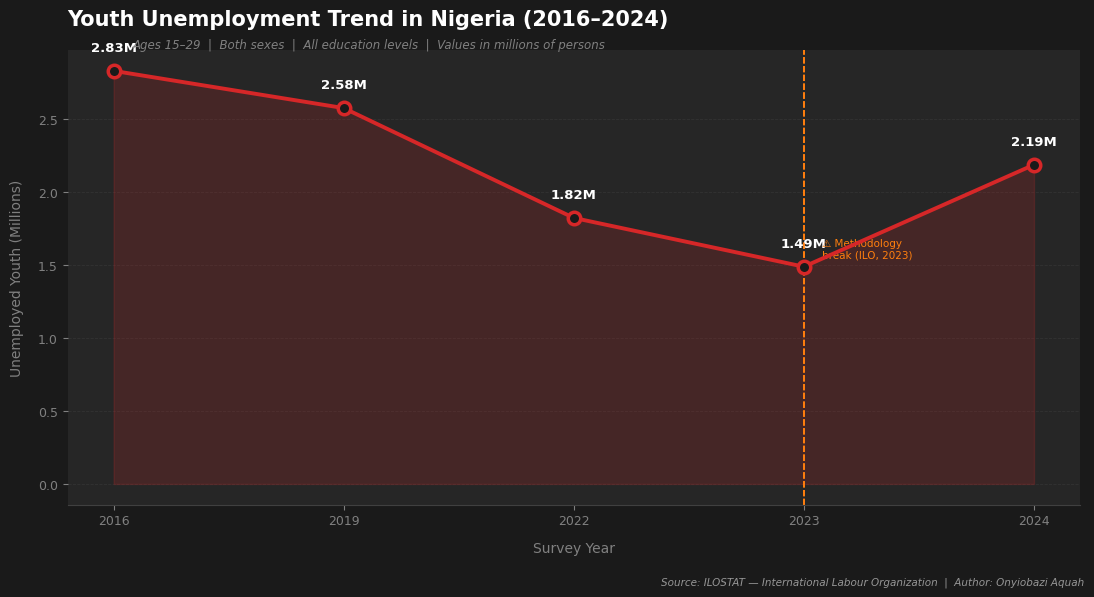

In [ ]:
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.fill_between(YEAR_LBLS, trend_vals, alpha=0.18, color=RED)
ax1.plot(
    YEAR_LBLS, trend_vals,
    color=RED, linewidth=2.8, zorder=5,
    marker='o', markersize=9,
    markerfacecolor=BG, markeredgecolor=RED, markeredgewidth=2.5
)
for x, v in zip(YEAR_LBLS, trend_vals):
    ax1.annotate(
        f"{v:.2f}M", xy=(x, v), xytext=(0, 14),
        textcoords='offset points', ha='center',
        fontsize=9.5, color=WHITE, fontweight='bold'
    )

    ax1.axvline(x='2023', color=GOLD, linewidth=1.2, linestyle='--', alpha=0.7)
ax1.text(3.08, trend_vals.min() + 0.05,
         "⚠ Methodology\nbreak (ILO, 2023)",
         fontsize=7.5, color=GOLD, va='bottom')

ax1.set_title(
    "Youth Unemployment Trend in Nigeria (2016–2024)",
    fontsize=15, fontweight='bold', color=WHITE, pad=18, loc='left'
)
ax1.set_xlabel("Survey Year", fontsize=10, labelpad=10, color=GREY)
ax1.set_ylabel("Unemployed Youth (Millions)", fontsize=10, labelpad=10, color=GREY)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.tick_params(axis='both', labelsize=9)

fig1.text(0.125, 0.91, 'Ages 15–29  |  Both sexes  |  All education levels  |  Values in millions of persons', fontsize=8.5, color='GREY', style='italic')

add_source(fig1)
fig1.tight_layout(rect=[0, 0.04, 1, 1])
save(fig1, "chart1_trend.png")
plt.show()

## Unemployment Share by Education Level

##### Does higher education reduce unemployment among youths? Is there evidence of an education-employment mismatch?

Saved: chart2_education_share.png


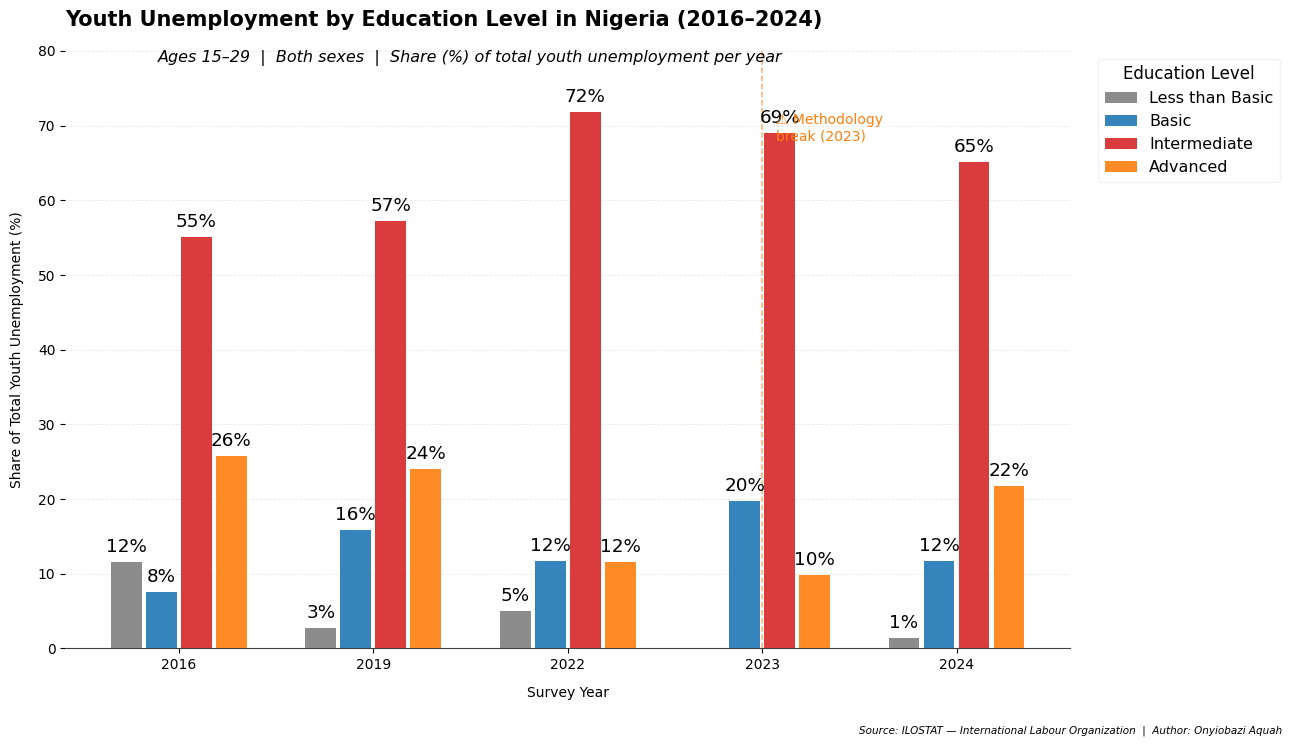

In [ ]:
x       = np.arange(len(YEARS))
width   = 0.18
n_edu   = len(EDU_ORDER)
offsets = np.linspace(-(n_edu-1)/2 * width, (n_edu-1)/2 * width, n_edu)


BG_WHITE = 'white'
TEXT_COLOR_DARK = 'black'
GRIDLINE_LIGHT = '#D0D0D0'

fig2, ax2 = plt.subplots(figsize=(13, 7.5), facecolor=BG_WHITE)
ax2.set_facecolor(BG_WHITE)

for i, (edu, color) in enumerate(zip(pivot_edu.index, EDU_COLORS)):
    row  = pivot_edu.loc[edu]
    bars = ax2.bar(
        x + offsets[i], row.values,
        width=width * 0.88, color=color, alpha=0.9, label=edu, zorder=3
    )
    for bar, val in zip(bars, row.values):
        if not np.isnan(val):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{val:.0f}%",
                ha='center', va='bottom', fontsize=13.2, color=TEXT_COLOR_DARK
            )

ax2.set_xticks(x)
ax2.set_xticklabels(YEAR_LBLS, fontsize=10, color=TEXT_COLOR_DARK)
ax2.set_ylabel("Share of Total Youth Unemployment (%)", fontsize=10, color=TEXT_COLOR_DARK, labelpad=10)
ax2.set_xlabel("Survey Year", fontsize=10, color=TEXT_COLOR_DARK, labelpad=10)


ax2.tick_params(axis='y', colors=TEXT_COLOR_DARK)

ax2.tick_params(axis='x', colors=TEXT_COLOR_DARK)


ax2.yaxis.grid(True, linestyle='--', alpha=0.45, color=GRIDLINE_LIGHT)
ax2.set_axisbelow(True)
ax2.set_ylim(0, 80)

ax2.axvline(x=3, color=GOLD, linewidth=1.1, linestyle='--', alpha=0.6)
ax2.text(3.07, 68, "⚠ Methodology\nbreak (2023)", fontsize=10, color=GOLD)

ax2.set_title(
    "Youth Unemployment by Education Level in Nigeria (2016–2024)",
    fontsize=15, fontweight='bold', color=TEXT_COLOR_DARK, pad=18, loc='left'
)
fig2.text(
    0.125, 0.91,
    "Ages 15–29  |  Both sexes  |  Share (%) of total youth unemployment per year",
    fontsize=11.5, color=TEXT_COLOR_DARK, style='italic'
)

legend = ax2.legend(
    title='Education Level', fontsize=11.5, title_fontsize=12,
    framealpha=0.25, facecolor=BG_WHITE, edgecolor=GRIDLINE_LIGHT,
    loc='upper left', bbox_to_anchor=(1.02, 1), labelcolor=TEXT_COLOR_DARK
)
legend.get_title().set_color(TEXT_COLOR_DARK)


fig2.text(
    0.99, 0.012,
    "Source: ILOSTAT — International Labour Organization  |  Author: Onyiobazi Aquah",
    ha='right', va='bottom', fontsize=7.5, color=TEXT_COLOR_DARK, style='italic'
)

fig2.tight_layout(rect=[0, 0.04, 1, 1])
save(fig2, "chart2_education_share.png")
plt.show()

## Education Composition 2016 vs 2024

#### Is there evidence of an education-employment mismatch?

Saved: chart3_mismatch_2016_vs_2024.png


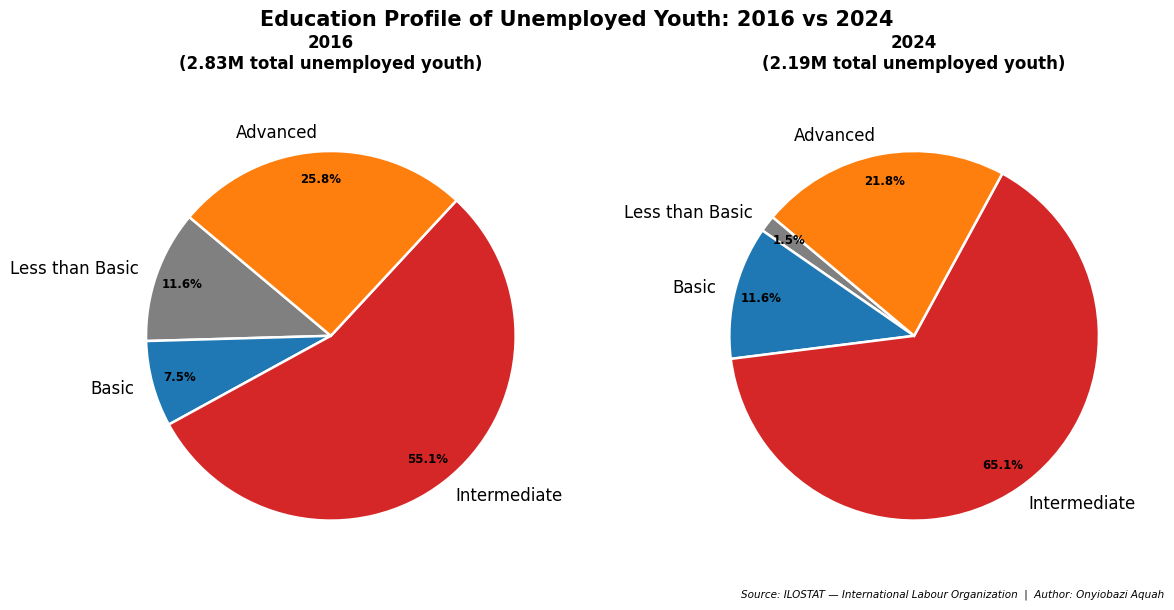

In [ ]:
fig3, axes = plt.subplots(1, 2, figsize=(12, 6.5))
fig3.patch.set_facecolor(BG_WHITE)
fig3.suptitle(
    "Education Profile of Unemployed Youth: 2016 vs 2024",
    fontsize=15, fontweight='bold', color=TEXT_COLOR_DARK, y=0.92
)

for ax, yr in zip(axes, [2016, 2024]):
    yr_data = edu_df[edu_df['Time Period'] == yr].set_index('Edu')['Share']
    yr_data = yr_data.reindex(EDU_ORDER).dropna()

    wedges, texts, autotexts = ax.pie(
        yr_data.values,
        labels=yr_data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=EDU_COLORS[:len(yr_data)],
        pctdistance=0.85,
        wedgeprops=dict(linewidth=1.8, edgecolor=BG_WHITE),
    )

    for t in texts:
        t.set_color(TEXT_COLOR_DARK)
        t.set_fontsize(12)
    for at in autotexts:
        at.set_color(TEXT_COLOR_DARK)
        at.set_fontsize(8.5)
        at.set_fontweight('bold')

        total_millions = totals_by_year[yr] / 1000
    ax.set_title(
        f"{yr}\n({total_millions:.2f}M total unemployed youth)",
        fontsize=12, fontweight='bold', color=TEXT_COLOR_DARK, pad=26
    )
    ax.set_facecolor(BG_WHITE)

fig3.text(
    0.99, 0.012,
    "Source: ILOSTAT — International Labour Organization  |  Author: Onyiobazi Aquah",
    ha='right', va='bottom', fontsize=7.5, color=TEXT_COLOR_DARK, style='italic'
)

fig3.tight_layout(rect=[0, 0.04, 1, 0.9])
save(fig3, "chart3_mismatch_2016_vs_2024.png")
plt.show()

##### This answers the question of if the education-employment mismatch changed over eight years, both male and females sexes put into consideration within the youth age gap of ages 15 to 29

## Educated Youth as Share of Total Unemployment

Saved: chart4_mismatch_trend.png


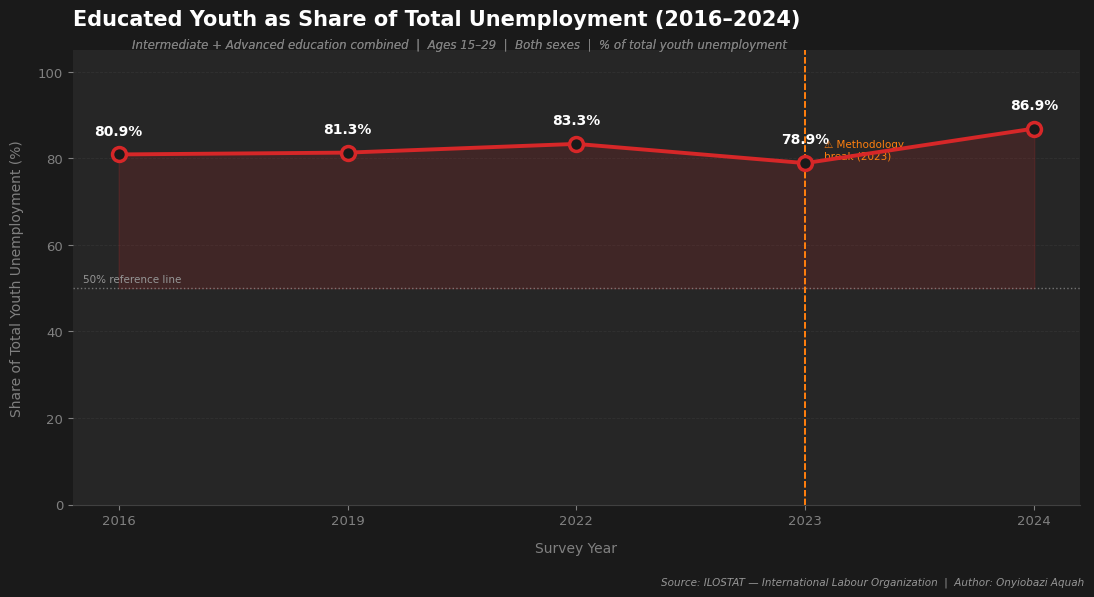

In [ ]:
high_edu_by_year = edu_df[
    edu_df['Edu'].isin(['Intermediate', 'Advanced'])
].groupby('Time Period')['Observed_Values'].sum()

mismatch_pct = (high_edu_by_year / totals_by_year * 100).reindex(YEARS)

fig4, ax4 = plt.subplots(figsize=(11, 6))

ax4.axhline(50, color=MUTED, linewidth=1, linestyle=':', alpha=0.7)
ax4.text(
    0.01, 51.5, "50% reference line",
    fontsize=7.5, color=MUTED, transform=ax4.get_yaxis_transform()
)

ax4.fill_between(
    YEAR_LBLS, mismatch_pct.values, 50,
    where=mismatch_pct.values >= 50,
    alpha=0.15, color=RED, interpolate=True
)

ax4.plot(
    YEAR_LBLS, mismatch_pct.values,
    color=RED, linewidth=2.8,
    marker='o', markersize=10,
    markerfacecolor=BG, markeredgecolor=RED, markeredgewidth=2.5,
    zorder=5
)


for x, v in zip(YEAR_LBLS, mismatch_pct.values):
    ax4.annotate(
        f"{v:.1f}%", xy=(x, v), xytext=(0, 14),
        textcoords='offset points', ha='center',
        fontsize=10, color=WHITE, fontweight='bold'
    )

    ax4.axvline(x='2023', color=GOLD, linewidth=1.2, linestyle='--', alpha=0.7)
ax4.text(
    3.08, mismatch_pct.values.min() + 1,
    "⚠ Methodology\nbreak (2023)", fontsize=7.5, color=GOLD
)

ax4.set_title(
    "Educated Youth as Share of Total Unemployment (2016–2024)",
    fontsize=15, fontweight='bold', color=WHITE, pad=18, loc='left'
)
fig4.text(
    0.125, 0.91,
    "Intermediate + Advanced education combined  |  Ages 15–29  |  Both sexes  |  % of total youth unemployment",
    fontsize=8.5, color=GREY, style='italic'
)
ax4.set_xlabel("Survey Year", fontsize=10, color=GREY, labelpad=10)
ax4.set_ylabel("Share of Total Youth Unemployment (%)", fontsize=10, color=GREY, labelpad=10)
ax4.set_ylim(0, 105)
ax4.yaxis.grid(True, linestyle='--', alpha=0.45)
ax4.set_axisbelow(True)
ax4.tick_params(axis='both', labelsize=9.5)

ax4.set_title(
    "Educated Youth as Share of Total Unemployment (2016–2024)",
    fontsize=15, fontweight='bold', color=WHITE, pad=18, loc='left'
)
fig4.text(
    0.125, 0.91,
    "Intermediate + Advanced education combined  |  Ages 15–29  |  Both sexes  |  % of total youth unemployment",
    fontsize=8.5, color=GREY, style='italic'
)
ax4.set_xlabel("Survey Year", fontsize=10, color=GREY, labelpad=10)
ax4.set_ylabel("Share of Total Youth Unemployment (%)", fontsize=10, color=GREY, labelpad=10)
ax4.set_ylim(0, 105)
ax4.yaxis.grid(True, linestyle='--', alpha=0.45)
ax4.set_axisbelow(True)
ax4.tick_params(axis='both', labelsize=9.5)

add_source(fig4)
fig4.tight_layout(rect=[0, 0.04, 1, 1])
save(fig4, "chart4_mismatch_trend.png")
plt.show()

In [ ]:
print("\n" + "="*60)
print("  All 4 charts exported successfully.")
print("  Files saved:")
print("    chart1_trend.png")
print("    chart2_education_share.png")
print("    chart3_mismatch_2016_vs_2024.png")
print("    chart4_mismatch_trend.png")
print("="*60)


  All 4 charts exported successfully.
  Files saved:
    chart1_trend.png
    chart2_education_share.png
    chart3_mismatch_2016_vs_2024.png
    chart4_mismatch_trend.png
